<a href="https://colab.research.google.com/github/Anupam-09/Skin_cancer_detection/blob/main/EffecientNet%26Resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# TensorFlow and Keras for building and training the neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# For working with image files and paths
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
from google.colab import files
files.upload()  # Upload your kaggle.json here (from Kaggle > Account > API > Create New API Token)

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"miniproject0910","key":"0c6bf67ade0d8c600a7c38675ea173f9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d HAM10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:50<00:00, 110MB/s]



In [ ]:
import shutil

merged_dir = '/content/HAM10000/all_images'
os.makedirs(merged_dir, exist_ok=True)

part1 = '/content/HAM10000/HAM10000_images_part_1'
part2 = '/content/HAM10000/HAM10000_images_part_2'

for folder in [part1, part2]:
    for img in os.listdir(folder):
        shutil.copy(os.path.join(folder, img), merged_dir)

print(f"✅ Total images merged: {len(os.listdir(merged_dir))}")

✅ Total images merged: 10015


In [ ]:
import pandas as pd

metadata_path = '/content/HAM10000/HAM10000_metadata.csv'
df = pd.read_csv(metadata_path)

print(f"✅ Metadata loaded: {df.shape[0]} rows")
df.head()


✅ Metadata loaded: 10015 rows


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


image_dir = '/content/HAM10000/all_images'


df['image_path'] = df['image_id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))


df = df[df['image_path'].apply(os.path.exists)]


label_mapping = {
    'akiec': 'Actinic keratoses',
    'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis-like lesions',
    'df': 'Dermatofibroma',
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'vasc': 'Vascular lesions'
}

df['label_name'] = df['dx'].map(label_mapping)


le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])


label_encoder_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding map:", label_encoder_map)



Label encoding map: {'akiec': np.int64(0), 'bcc': np.int64(1), 'bkl': np.int64(2), 'df': np.int64(3), 'mel': np.int64(4), 'nv': np.int64(5), 'vasc': np.int64(6)}


/tmp/ipykernel_1215/2313735150.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='Set2')


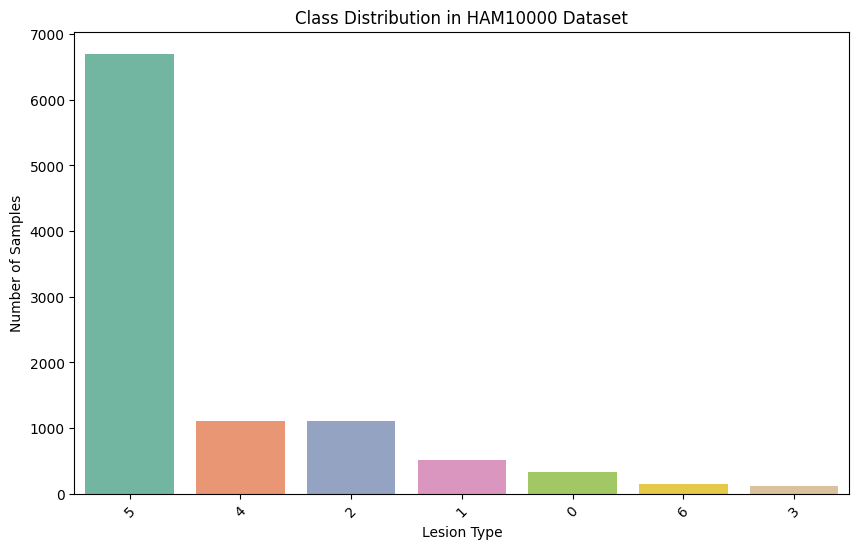

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='Set2')
plt.title("Class Distribution in HAM10000 Dataset")
plt.xlabel("Lesion Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import cv2
image_size = 128
images = []

for path in df['image_path']:
    img = cv2.imread(path)
    img = cv2.resize(img, (image_size, image_size))
    images.append(img)

datagen = ImageDataGenerator(rescale=1.0/255)


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

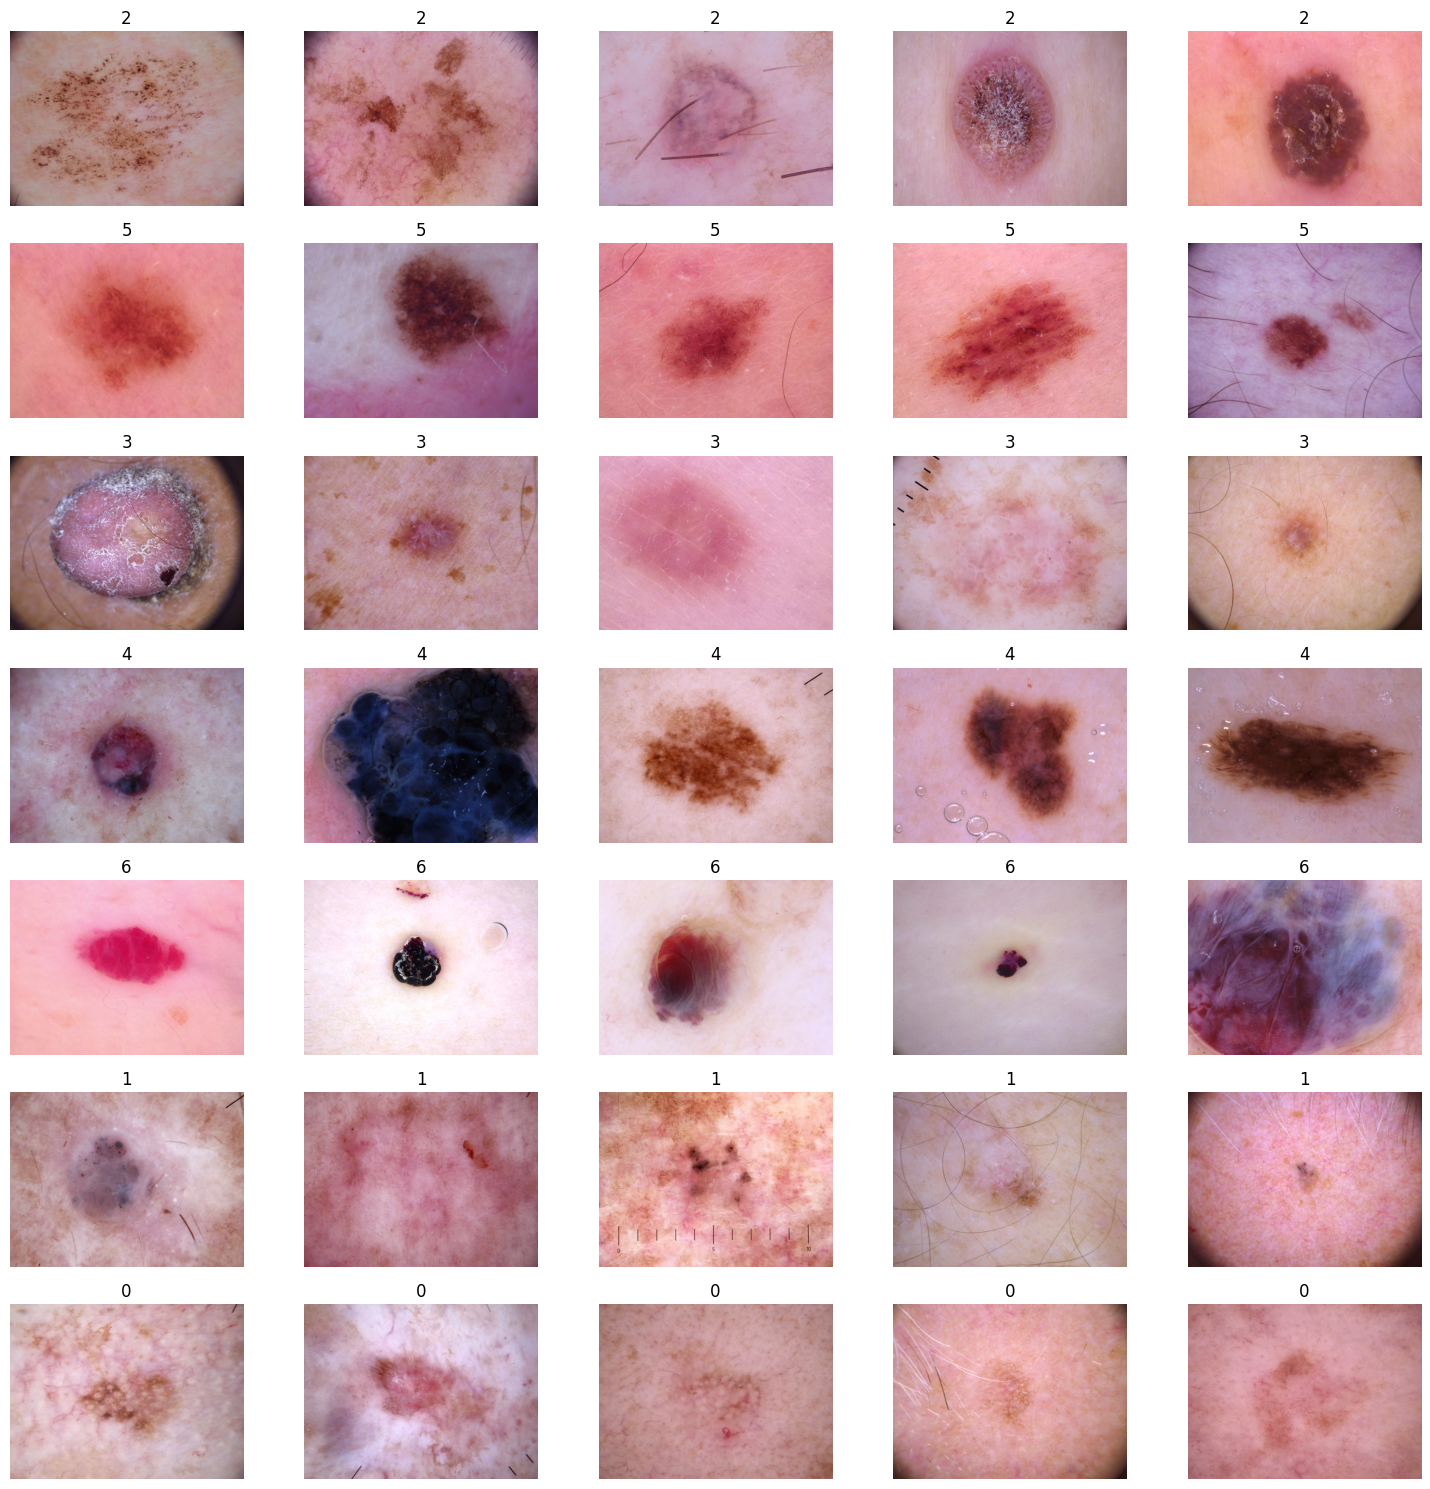

In [ ]:
import random
import os
from PIL import Image

plt.figure(figsize=(15, 15))
class_names = df['label'].unique()
for i, label in enumerate(class_names):
    sample_images = df[df['label'] == label].sample(5)
    for j, image_path in enumerate(sample_images['image_path']):
        img = Image.open(image_path)
        plt.subplot(len(class_names), 5, i*5 + j + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_df['label'] = train_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

In [ ]:
#data generation
train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=( 128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_gen = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(layers.MaxPooling2D((2, 2)))  # Output: 32x32

# Conv Layer 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))  # Output: 16x16

# Conv Layer 3
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))  # Output: 8x8

# Flatten and Dense Layers
model.add(layers.Flatten())  # Output: 8x8x128 = 8192
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(7, activation='softmax'))  # 7 classes

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.6664 - loss: 1.0469 - val_accuracy: 0.6715 - val_loss: 0.8925
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.6700 - loss: 0.9176 - val_accuracy: 0.6795 - val_loss: 0.8545
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - accuracy: 0.6747 - loss: 0.8869 - val_accuracy: 0.6825 - val_loss: 0.8760
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.6845 - loss: 0.8578 - val_accuracy: 0.6800 - val_loss: 0.8332
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - accuracy: 0.6930 - loss: 0.8151 - val_accuracy: 0.6965 - val_loss: 0.8336
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.7002 - loss: 0.7924 - val_accuracy: 0.6905 - val_loss: 0.8344
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.7126 - loss: 0.7557 - val_accuracy: 0.7204 - val_loss: 0.7475
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.7200 - loss: 0.7352 - val_accu

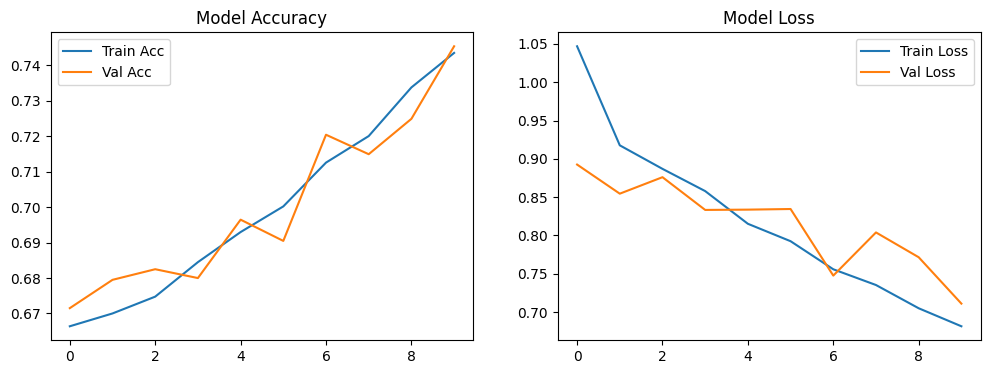

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [ ]:
model.save("skin_cancer_model7.h5")

In [ ]:
from google.colab import files
files.download('skin_cancer_model7.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EfficientNet Model :

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')  # 7 skin cancer classes
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

In [ ]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen
)

ResNet

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # We’ll fine-tune later

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')  # 7 classes
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


In [ ]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen
)